# Support Vector Machines (SVM) - Part 1: The Intuition

Welcome! Today we are learning about **Support Vector Machines (SVM)**. This is a popular machine learning model used to classify data into different groups.

### 1. The Intuition: The 'Street Analogy'

Imagine you are a city planner standing in a field of two types of flowers: **Setosa** and **Versicolor**. Your goal is to build the **widest possible street** that separates these two groups so that no flower is actually touched by the pavement.

*   **The Hyperplane (The Middle Line):** This is the yellow line painted down the very center of your street. In our 2D plot, it's just a line that decides which side a flower belongs to.
*   **The Margin (The Width):** This is the total width of the street. SVM doesn't just want a thin line; it wants the **widest possible gap** between the groups to ensure it doesn't make mistakes on new flowers later.
*   **Support Vectors (The Edge Flowers):** These are the specific flowers that sit right at the very edge of the street. They 'support' the boundaries. If you moved one of these flowers, the entire street would have to shift!

In [ ]:
import pandas as pd # Import pandas to handle data in tables
from sklearn.datasets import load_iris # Import the helper to load the Iris dataset

# 1. Load the raw data from sklearn
iris = load_iris()

# 2. Convert the data into a Pandas DataFrame for easier viewing
# We use iris.data for the numbers and iris.feature_names for column headers
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# 3. Add the 'target' column (the flower species) to our DataFrame
df['species'] = iris.target

# 4. Simplify the problem: Keep only the first 100 rows
# Species 0 (Setosa) and 1 (Versicolor) occupy the first 100 rows.
# We exclude species 2 (Virginica) to make the classification easier to see.
df = df.iloc[:100]

# 5. Simplify the features: Keep only Petal Length and Petal Width
# We choose only 2 features so we can draw them on a 2D (X and Y) graph.
df = df[['petal length (cm)', 'petal width (cm)', 'species']]

# Display the first 5 rows to check our work
display(df.head())

,petal length (cm),petal width (cm),species
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0


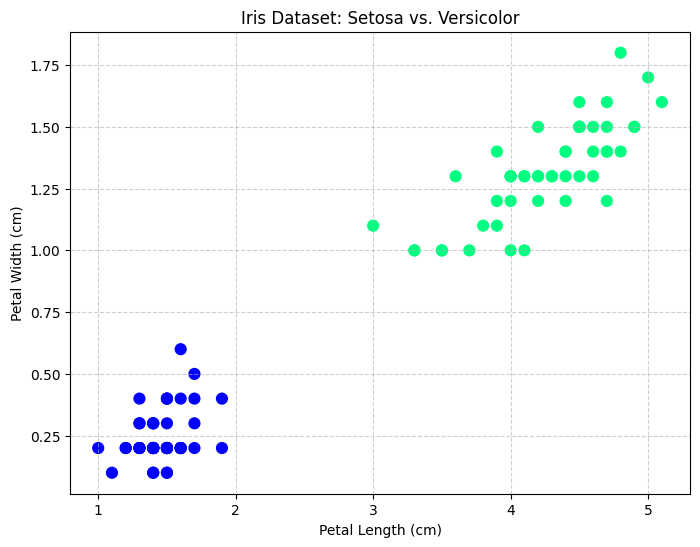

In [ ]:
import matplotlib.pyplot as plt # Import the plotting library

# 1. Create a new figure with a specific size (8 inches wide, 6 inches high)
plt.figure(figsize=(8, 6))

# 2. Create a scatter plot
# x: Petal length on the horizontal axis
# y: Petal width on the vertical axis
# c: Color the points based on the 'species' column (0 or 1)
# cmap: Use the 'winter' color map for nice blues and greens
# s: Set the size of each dot to 60
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['species'], cmap='winter', s=60)

# 3. Add a descriptive title to the top of the plot
plt.title('Iris Dataset: Setosa vs. Versicolor')

# 4. Label the horizontal X-axis
plt.xlabel('Petal Length (cm)')

# 5. Label the vertical Y-axis
plt.ylabel('Petal Width (cm)')

# 6. Add a grid in the background to make it easier to read coordinates
plt.grid(True, linestyle='--', alpha=0.6)

# 7. Show the final plot to the user
plt.show()

# Support Vector Machines (SVM) - Part 2: Training & Visualizing the Boundary

Now that we have visualized our flowers, let's train a model to find the best possible separation between them.

### 1. What is a Linear Kernel?
In SVM, a **Kernel** is the mathematical function used to determine the shape of the boundary. A **Linear Kernel** means we want to draw a perfectly straight line (in 2D) or a flat plane (in 3D) to separate our data. It is the simplest and most interpretable type of SVM.

### 2. The 'C' Parameter (The Budget for Mistakes)
The `C` parameter is one of the most important settings in SVM:
*   **Small C (Soft Margin):** The model is 'relaxed.' it allows some flowers to be on the wrong side of the street if it means the street can be wider overall. This helps avoid 'overfitting.'
*   **Large C (Hard Margin):** The model is 'strict.' It tries to classify every single flower correctly, even if it makes the street very narrow or crooked.

For this lesson, we will use `C=1.0` as a balanced starting point.

In [ ]:
from sklearn.svm import SVC # Import the Support Vector Classifier
import numpy as np # Import numpy for numerical operations

# 1. Prepare our features (X) and our labels (y)
# X = Petal Length and Petal Width
# y = The species (0 or 1)
X = df[['petal length (cm)', 'petal width (cm)']].values
y = df['species'].values

# 2. Initialize the Support Vector Classifier
# kernel='linear': We want a straight line boundary
# C=1.0: Our 'strictness' level for classification
model = SVC(kernel='linear', C=1.0)

# 3. 'Train' the model
# This is where the SVM math finds the widest possible street
model.fit(X, y)

print("Model training complete!")

Model training complete!


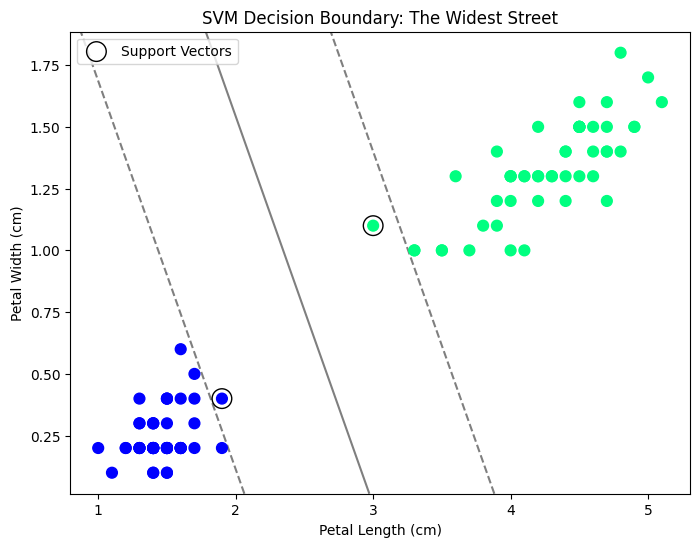

In [ ]:
def plot_svm_boundary(model, X, y):
    # 1. Create the base scatter plot of our flowers
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=60, cmap='winter', zorder=3)

    # 2. Get the current axes limits to draw the lines within the box
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # 3. Create a grid of points to evaluate the model's 'decision'
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # 4. Calculate the distance of every point in the grid from the 'street'
    Z = model.decision_function(xy).reshape(XX.shape)

    # 5. Plot the decision boundary (the center line) and the margins (the edges)
    # levels=[-1, 0, 1]: -1 is the left edge, 0 is the center, 1 is the right edge
    # linestyles=['--', '-', '--']: Dashed for edges, solid for the center
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # 6. Highlight the Support Vectors!
    # These are the specific flowers the model used to define the street.
    # We draw large, empty circles around them to make them stand out.
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=200,
               linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

    # 7. Add labels and title
    plt.title('SVM Decision Boundary: The Widest Street')
    plt.xlabel('Petal Length (cm)')
    plt.ylabel('Petal Width (cm)')
    plt.legend()
    plt.show()

# Run the function to see the results!
plot_svm_boundary(model, X, y)

### Why are the Support Vectors circled?

Notice the flowers with the black circles around them. These are the **Support Vectors**.

In an SVM model, these are the **only** data points that matter! If you moved any of the other flowers (the ones far away from the street), the street would stay exactly where it is. But if you moved just one Support Vector, the entire street would have to shift or tilt to stay as wide as possible.

This makes SVMs very efficient, as they only need to 'remember' a few key points to make perfect decisions!

# Support Vector Machines (SVM) - Part 3: The Overlap Challenge & The Kernel Trick

In the real world, data is rarely as neat and tidy as our first two groups. Most of the time, different categories overlap, and a simple straight line (Linear Kernel) just won't cut it.

### 1. The Overlap Challenge
Let's load the full Iris dataset, including the third species: **Virginica**. You will see that while Setosa is easy to separate, Versicolor and Virginica blend into each other.

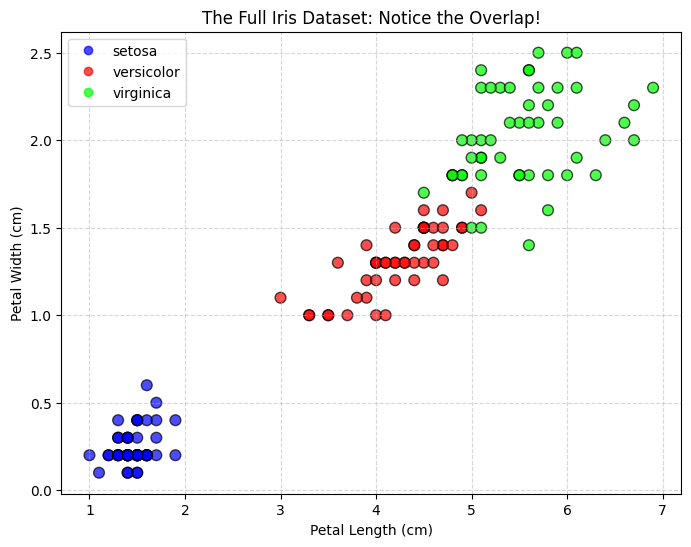

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 1. Load the full dataset (all 150 rows)
iris = load_iris()
df_full = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_full['species'] = iris.target

# 2. Keep only Petal Length and Petal Width for visualization
df_full = df_full[['petal length (cm)', 'petal width (cm)', 'species']]

# 3. Plot all three species to see the overlap
plt.figure(figsize=(8, 6))
# We use the 'brg' colormap for Blue, Red, and Green clusters
scatter = plt.scatter(df_full['petal length (cm)'], df_full['petal width (cm)'],
            c=df_full['species'], cmap='brg', s=60, edgecolors='k', alpha=0.7)

plt.title('The Full Iris Dataset: Notice the Overlap!')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 2. The Kernel Trick (The RBF Kernel)

When data overlaps like this, we use the **Kernel Trick**.

Imagine the dots are lying on a flat sheet of paper and you can't separate them with a ruler. The Kernel Trick 'lifts' the paper into 3D space, making some dots higher than others. Suddenly, you can slide a flat sheet between them! When we project that boundary back down to our 2D paper, it looks like a **curved line**.

*   **RBF (Radial Basis Function):** This is the most popular kernel. It creates 'circular' regions around data points.
*   **Gamma:** This controls the 'influence' of a single point. A **high gamma** means the boundary hugs every point closely (high detail), while a **low gamma** makes the boundary smoother and more general.

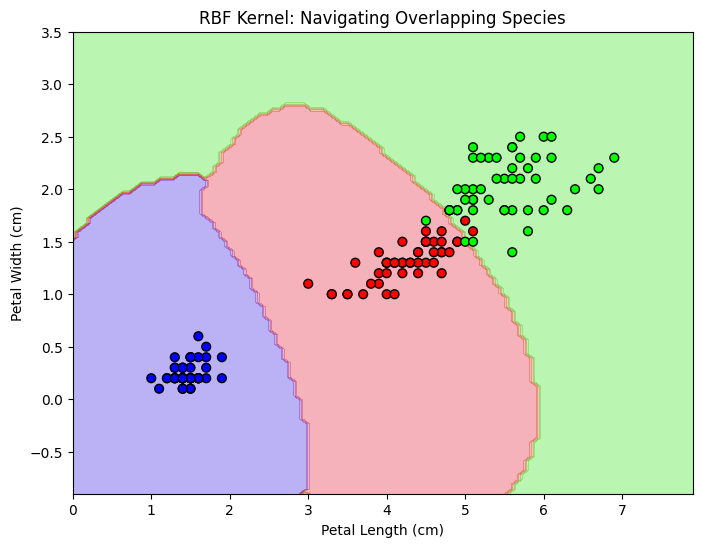

In [ ]:
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Prepare all data points
X_full = df_full[['petal length (cm)', 'petal width (cm)']].values
y_full = df_full['species'].values

# 2. Initialize and train the RBF SVM
# kernel='rbf': Use the non-linear 'Kernel Trick'
# C=1.0: Balanced strictness
# gamma=0.5: How much influence each point has
rbf_model = SVC(kernel='rbf', C=1.0, gamma=0.5)
rbf_model.fit(X_full, y_full)

# 3. Visualize the Curved Decision Regions
plt.figure(figsize=(8, 6))
# This tool automatically draws the colored background regions
DecisionBoundaryDisplay.from_estimator(
    rbf_model, X_full, response_method="predict",
    cmap='brg', alpha=0.3, ax=plt.gca()
)

# Overlay the actual flowers
plt.scatter(X_full[:, 0], X_full[:, 1], c=y_full, cmap='brg', s=40, edgecolors='k')
plt.title('RBF Kernel: Navigating Overlapping Species')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

Model Accuracy: 96.67%


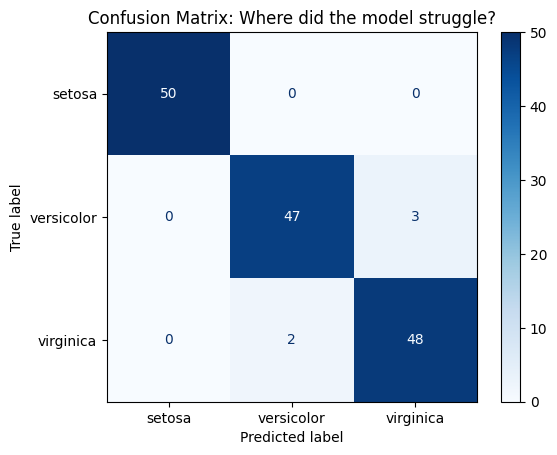

In [ ]:
# 1. Predict the species for all our flowers using the new model
y_pred = rbf_model.predict(X_full)

# 2. Calculate the Accuracy Score (Percentage of correct guesses)
accuracy = accuracy_score(y_full, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 3. Create a Confusion Matrix to see exactly where the model got confused
cm = confusion_matrix(y_full, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Where did the model struggle?')
plt.show()

### Congratulations!

You have successfully used Support Vector Machines to classify real-world botanical data!

In this lesson, you went from drawing simple **linear streets** with clear margins to using the **Kernel Trick** to navigate complex, overlapping species. You've learned how `C` and `Gamma` control the model's behavior and how to evaluate your success using a Confusion Matrix. You are now ready to apply SVM to even more complex datasets!